# Demand Forecasting & Late Delivery Risk (Supply Chain)

**Dataset:** DataCo Smart Supply Chain (Kaggle), ~180,000 order-line records, 2015–2017.

**Problem:** A supply chain team needs to (1) forecast daily demand by product category to plan inventory,
and (2) flag orders likely to arrive late so they can be expedited before they miss their promised window.
Poor forecasts cause stockouts and overstock; late deliveries damage customer trust and can trigger
contractual penalties.

**What this notebook does**
1. Cleans the data and removes personal fields.
2. Explores demand trend and seasonality, and late-delivery rates by shipping mode, region, and category.
3. Builds a daily category-level demand series with lag and rolling-average features.
4. Forecasts demand (baseline vs. Linear Regression vs. Random Forest) on a date-based split.
5. Predicts late delivery at order placement (Logistic Regression vs. Random Forest), without any
   post-delivery information.
6. Summarises findings and recommendations for operations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, RocCurveDisplay, PrecisionRecallDisplay)

np.random.seed(42)
sns.set_style('whitegrid')

## Section 1: Load and Clean the Data

The raw CSV is not UTF-8 encoded, so it is loaded with `encoding='latin1'`. The data file is not in
the repository; download it from Kaggle (see the README) and place it in `data/`.

In [2]:
df = pd.read_csv('data/DataCoSupplyChainDataset.csv', encoding='latin1')
print(df.shape)

(180519, 53)


### Clean up column names

The column names in the export are inconsistent (mixed case, spaces, parentheses). They are renamed to
snake_case. Personal fields (customer email, names, password, street) and columns that are empty or
not needed (`product_description`, `product_image`, `order_zipcode`) are removed.

In [3]:
rename_map = {
    'Type': 'type',
    'Days for shipping (real)': 'days_shipping_real',
    'Days for shipment (scheduled)': 'days_shipment_scheduled',
    'Benefit per order': 'benefit_per_order',
    'Sales per customer': 'sales_per_customer',
    'Delivery Status': 'delivery_status',
    'Late_delivery_risk': 'late_delivery_risk',
    'Category Id': 'category_id',
    'Category Name': 'category_name',
    'Customer City': 'customer_city',
    'Customer Country': 'customer_country',
    'Customer Email': 'customer_email',
    'Customer Fname': 'customer_forename',
    'Customer Id': 'customer_id',
    'Customer Lname': 'customer_lastname',
    'Customer Password': 'customer_password',
    'Customer Segment': 'customer_segment',
    'Customer State': 'customer_state',
    'Customer Street': 'customer_street',
    'Customer Zipcode': 'customer_zipcode',
    'Department Id': 'department_id',
    'Department Name': 'department_name',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Market': 'market',
    'Order City': 'order_city',
    'Order Country': 'order_country',
    'Order Customer Id': 'order_customer_id',
    'order date (DateOrders)': 'order_date',
    'Order Id': 'order_id',
    'Order Item Cardprod Id': 'order_item',
    'Order Item Discount': 'order_item_discount',
    'Order Item Discount Rate': 'order_item_discount_rate',
    'Order Item Id': 'order_item_id',
    'Order Item Product Price': 'order_item_product_price',
    'Order Item Profit Ratio': 'order_item_profit_ratio',
    'Order Item Quantity': 'order_item_quantity',
    'Sales': 'sales',
    'Order Item Total': 'order_item_total',
    'Order Profit Per Order': 'order_profit_per_order',
    'Order Region': 'order_region',
    'Order State': 'order_state',
    'Order Status': 'order_status',
    'Order Zipcode': 'order_zipcode',
    'Product Card Id': 'product_card_id',
    'Product Category Id': 'product_category_id',
    'Product Description': 'product_description',
    'Product Image': 'product_image',
    'Product Name': 'product_name',
    'Product Price': 'product_price',
    'Product Status': 'product_status',
    'shipping date (DateOrders)': 'shipping_date',
    'Shipping Mode': 'shipping_mode',
}
df = df.rename(columns=rename_map)

# Personal and placeholder fields: not needed for analysis
df = df.drop(columns=['customer_email', 'customer_forename', 'customer_lastname', 'customer_password',
                      'customer_street', 'product_image', 'product_description', 'order_zipcode'])

### Dates, duplicates, and the data cut-off

`order_date` and `shipping_date` are converted to datetimes. The dataset has no duplicate rows.

**Data cut-off:** the monthly order counts collapse from October 2017 onward (see the EDA below). This
is a collection cut-off, not a real change in demand, so only complete months (up to 30 Sep 2017) are
kept. This removes about 8,500 rows.

In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['shipping_date'] = pd.to_datetime(df['shipping_date'])
df['customer_zipcode'] = df['customer_zipcode'].fillna(0)
print('duplicated rows:', df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

duplicated rows: 0


(180519, 45)


In [5]:
# The raw data stops mid-October 2017: monthly row counts collapse from that point (see EDA below).
# Keep only complete months.
df = df[df['order_date'] < '2017-10-01'].copy()
print('date range:', df['order_date'].min(), '->', df['order_date'].max())
print(df.shape)

date range: 2015-01-01 00:00:00 -> 2017-09-30 23:59:00
(171962, 45)


## Section 2: Exploratory Data Analysis

### 2.1 Demand trend and seasonality

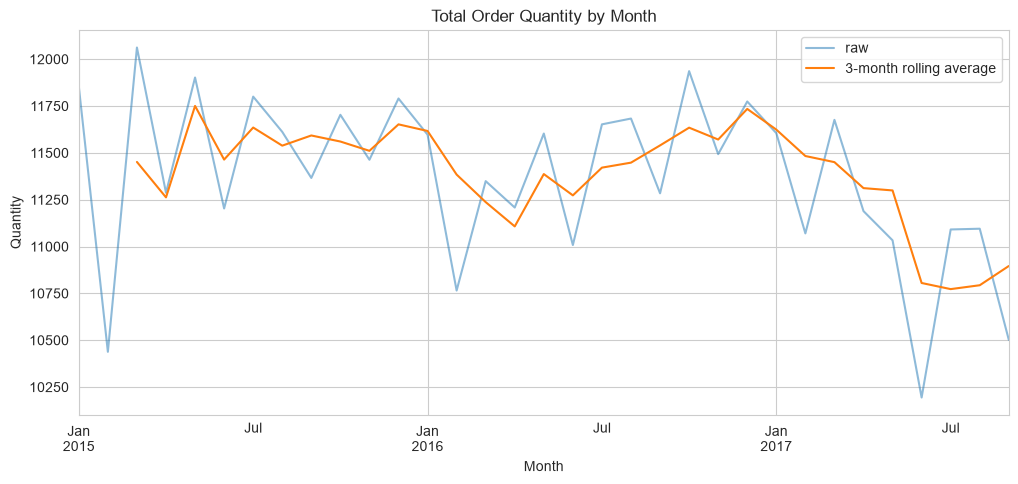

In [6]:
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_demand = df.groupby('order_month')['order_item_quantity'].sum()

monthly_demand.plot(alpha=0.5, label='raw')
monthly_demand.rolling(3).mean().plot(label='3-month rolling average', figsize=(12, 5))
plt.title('Total Order Quantity by Month')
plt.xlabel('Month')
plt.ylabel('Quantity')
plt.legend()
plt.show()

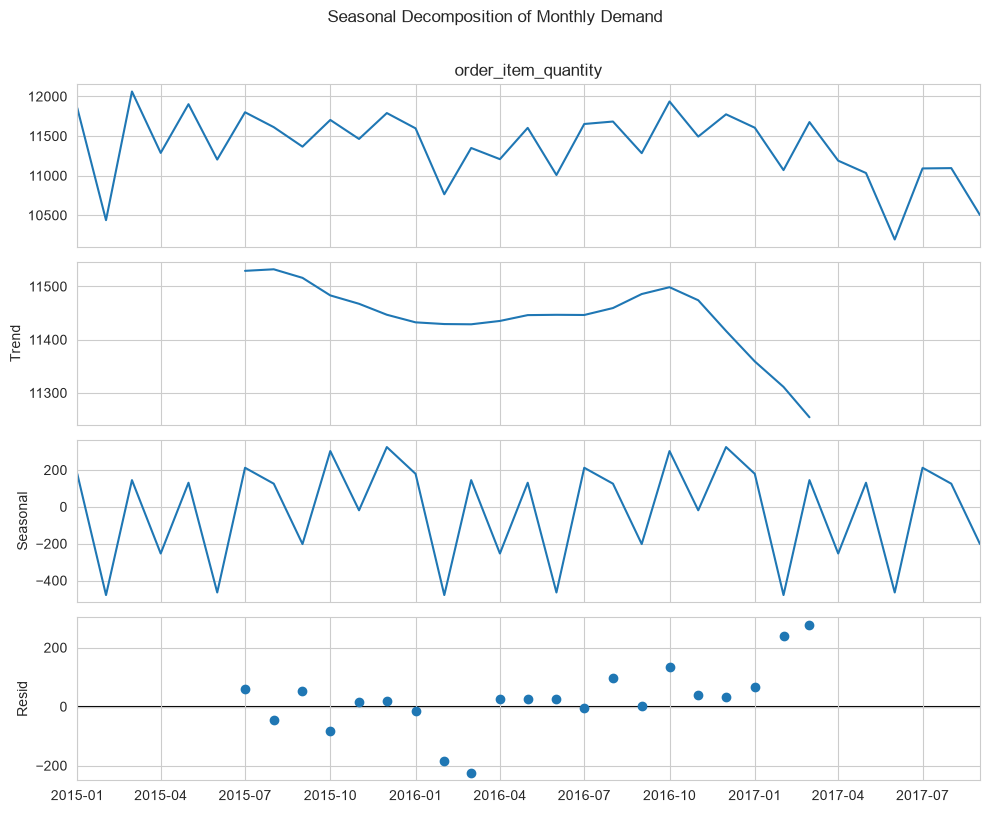

In [7]:
ts = monthly_demand.copy()
ts.index = ts.index.to_timestamp()
decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Seasonal Decomposition of Monthly Demand', y=1.01)
plt.tight_layout()
plt.show()

**Insight:** Monthly demand is broadly flat between 2015 and 2017 (roughly 10,000–12,000 units per month)
with no long-term growth or decline. The decomposition isolates a regular seasonal cycle: February tends
to be a low month each year, and the seasonal effect is smaller than the month-to-month noise.

shipping_mode
First Class       0.953
Second Class      0.766
Same Day          0.456
Standard Class    0.381
Name: late_delivery_risk, dtype: float64


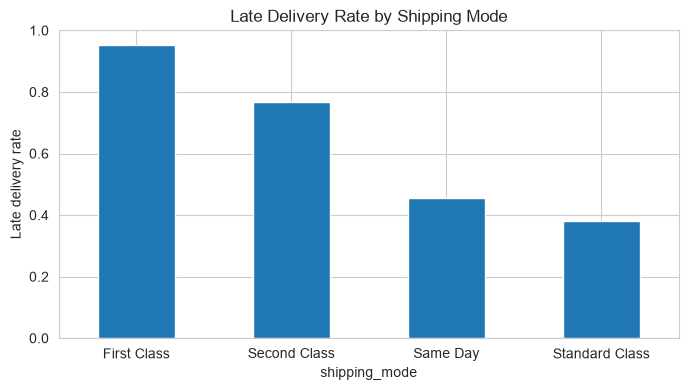

In [8]:
late_rate_by_mode = df.groupby('shipping_mode')['late_delivery_risk'].mean().sort_values(ascending=False)
print(late_rate_by_mode.round(3))
late_rate_by_mode.plot(kind='bar', figsize=(8, 4))
plt.title('Late Delivery Rate by Shipping Mode')
plt.ylabel('Late delivery rate')
plt.xticks(rotation=0)
plt.show()

### 2.2 Late delivery rate by shipping mode

Late delivery is the target of the classification model, so its relationship with shipping mode is
checked first.

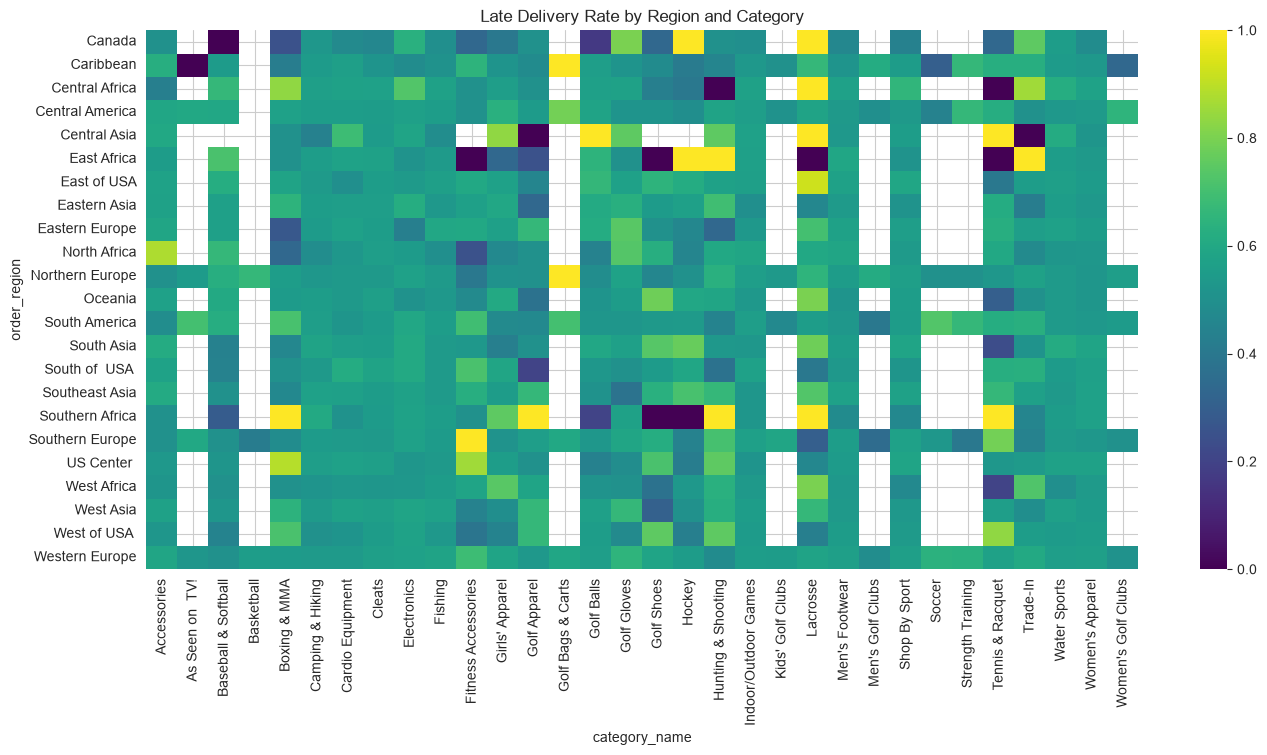

                 mean_risk  risk_std
order_region                        
Central Asia         0.598     0.269
East of USA          0.577     0.092
Southeast Asia       0.576     0.078
US Center            0.572     0.117
Southern Africa      0.568     0.286
South America        0.565     0.083
Western Europe       0.564     0.045
Central America      0.563     0.064
Northern Europe      0.558     0.097
South Asia           0.558     0.113
West of USA          0.557     0.112
Central Africa       0.554     0.219
Eastern Asia         0.553     0.075
West Asia            0.553     0.078
Eastern Europe       0.552     0.102
Oceania              0.548     0.100
Southern Europe      0.545     0.124
North Africa         0.542     0.123
West Africa          0.539     0.116
South of  USA        0.535     0.102
Caribbean            0.525     0.155
East Africa          0.500     0.291
Canada               0.496     0.228
                      mean_risk  risk_std
category_name                    

In [9]:
pivot = df.pivot_table(index='order_region', columns='category_name',
                       values='late_delivery_risk', aggfunc='mean')
plt.figure(figsize=(16, 7))
sns.heatmap(pivot, cmap='viridis')
plt.title('Late Delivery Rate by Region and Category')
plt.show()

region_summary = pd.DataFrame({'mean_risk': pivot.mean(axis=1), 'risk_std': pivot.std(axis=1)})
category_summary = pd.DataFrame({'mean_risk': pivot.mean(axis=0), 'risk_std': pivot.std(axis=0)})
print(region_summary.sort_values('mean_risk', ascending=False).round(3))
print(category_summary.sort_values('mean_risk', ascending=False).round(3))

**Insight:** Shipping mode is the strongest visible driver of late deliveries. First Class orders are late
95% of the time, Second Class 77%, Same Day 46%, and Standard Class 38%. The fastest, premium modes have
the highest late rates. This points to tight delivery promises (service-level design) rather than slower
carriers, since the faster modes promise much shorter windows.

In [10]:
volume = df.groupby('category_name')['order_item_quantity'].sum()
value = df.groupby('category_name')['sales'].sum()
summary = pd.DataFrame({'volume': volume, 'value': value})
summary['volume_rank'] = summary['volume'].rank(ascending=False)
summary['value_rank'] = summary['value'].rank(ascending=False)
print(summary.sort_values('value_rank').head(10))

                      volume         value  volume_rank  value_rank
category_name                                                      
Fishing                17308  6.922854e+06          7.0         1.0
Cleats                 73614  4.424744e+06          1.0         2.0
Camping & Hiking       13714  4.113926e+06          9.0         3.0
Cardio Equipment       37523  3.688444e+06          4.0         4.0
Women's Apparel        62878  3.143900e+06          2.0         5.0
Water Sports           15515  3.108845e+06          8.0         6.0
Men's Footwear         22214  2.887598e+06          6.0         7.0
Indoor/Outdoor Games   57735  2.885595e+06          3.0         8.0
Shop By Sport          32701  1.308522e+06          5.0         9.0
Electronics             9436  3.710346e+05         10.0        10.0


### 2.3 Late delivery rate by region and category

The region × category matrix shows whether risk depends on where a product ships, on what is shipped, or
both.

In [11]:
demand_ts = (df.groupby(['order_date', 'category_name'])['order_item_quantity'].sum()
               .rename('demand').reset_index()
               .rename(columns={'order_date': 'date'}))
demand_ts['date'] = demand_ts['date'].dt.normalize()
demand_ts = demand_ts.groupby(['date', 'category_name'], as_index=False)['demand'].sum()
demand_ts = demand_ts.sort_values(['category_name', 'date']).reset_index(drop=True)
print(demand_ts.shape)
demand_ts.head()

(16966, 3)


,date,category_name,demand
0,2015-01-01,Accessories,11
1,2015-01-02,Accessories,5
2,2015-01-03,Accessories,3
3,2015-01-05,Accessories,5
4,2015-01-07,Accessories,4


**Insight:**
- **Consistently risky regions** (high average late rate, low variation across categories): East of USA
  (mean 0.58, std 0.09), Southeast Asia (0.58, 0.08), Western Europe (0.56, 0.05), South America (0.57, 0.08).
- **Regions that depend on category** (high variation): Central Asia (0.60, std 0.27), Southern Africa
  (0.57, 0.29), East Africa (0.50, 0.29). Their overall rate is driven by specific categories.
- **Riskiest category overall:** Golf Bags & Carts, with a 78% average late rate, far above the next
  category (Lacrosse, 66%).
- **Most variable categories across regions:** Tennis & Racquet, Lacrosse, and "As Seen on TV!"
  (std 0.25–0.27).

Region and category should be read together: the same category can be low-risk in one region and high-risk
in another.

In [12]:
g = demand_ts.groupby('category_name')['demand']
demand_ts['day_of_week'] = demand_ts['date'].dt.dayofweek
demand_ts['month'] = demand_ts['date'].dt.month
demand_ts['is_weekend'] = demand_ts['day_of_week'].isin([5, 6]).astype(int)

for lag in [1, 7, 14, 28]:
    demand_ts[f'demand_lag_{lag}'] = g.shift(lag)
# Rolling windows exclude the current day (shift(1) first), so no information from the day being predicted
for w in [7, 14, 28]:
    demand_ts[f'demand_rolling_{w}'] = g.transform(lambda x: x.shift(1).rolling(w).mean())

lag_cols = [c for c in demand_ts.columns if c.startswith(('demand_lag', 'demand_rolling'))]
demand_ts = demand_ts.dropna(subset=lag_cols).reset_index(drop=True)
demand_ts = pd.get_dummies(demand_ts, columns=['category_name'], dtype=int)
print(demand_ts.shape)

(16079, 43)


### 2.4 Volume vs. value by category

In [13]:
X = demand_ts.drop(columns=['demand', 'date'])
y = demand_ts['demand']

train_end, val_end = '2017-04-01', '2017-07-01'
train_mask = demand_ts['date'] < train_end
val_mask = (demand_ts['date'] >= train_end) & (demand_ts['date'] < val_end)
test_mask = demand_ts['date'] >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
print('train/val/test:', X_train.shape, X_val.shape, X_test.shape)

train/val/test: (13157, 41) (1411, 41) (1511, 41)


**Insight:** Volume and value rankings only partly overlap. Cleats is in the top two for both volume and
value. Fishing is the highest-value category (about $6.9M in sales) but ranks 7th by units, so it is a
high-value, lower-volume category. Women's Apparel and Indoor/Outdoor Games rank high on units but lower on
value. Inventory decisions should weigh the cost of a stockout differently for these two groups.

In [14]:
# Baseline: tomorrow's demand = the 7-day rolling average already in the data
baseline_pred = X_test['demand_rolling_7']
def report(name, y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    r2 = r2_score(y_true, y_hat)
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = [report('Baseline (rolling-7)', y_test, baseline_pred)]
lr = LinearRegression().fit(X_train, y_train)
results.append(report('Linear Regression', y_test, lr.predict(X_test)))

## Section 3: Feature Engineering

The raw data is one row per order line. Demand is aggregated to one row per **category per day**, and
lag and rolling features are built on that daily series.

**Leakage check:** every lag and rolling feature is computed from days *before* the day being predicted.
Rolling averages are shifted by one day first, so the current day's demand is never used to predict itself.

In [15]:
# Tune the Random Forest on the validation set only
grid = [(d, l) for d in [5, 8, 12, None] for l in [1, 5, 10]]
val_scores = {}
for depth, leaf in grid:
    m = RandomForestRegressor(n_estimators=200, max_depth=depth, min_samples_leaf=leaf, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    val_scores[(depth, leaf)] = mean_absolute_error(y_val, m.predict(X_val))
best_depth, best_leaf = min(val_scores, key=val_scores.get)
print('best (max_depth, min_samples_leaf) on validation:', best_depth, best_leaf, round(val_scores[(best_depth, best_leaf)], 3))

rf = RandomForestRegressor(n_estimators=200, max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(report('Random Forest', y_test, rf.predict(X_test)))

best (max_depth, min_samples_leaf) on validation: 5 5 5.586


**Feature set:** day of week, month, weekend flag, lags of 1, 7, 14, and 28 days, rolling means over
7, 14, and 28 days, and one-hot category columns.

In [16]:
# Residual model: learn the correction on top of the rolling average
rf_resid = RandomForestRegressor(n_estimators=200, max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42, n_jobs=-1)
rf_resid.fit(X_train, y_train - X_train['demand_rolling_7'])
resid_pred = X_test['demand_rolling_7'] + rf_resid.predict(X_test)
results.append(report('Residual Random Forest', y_test, resid_pred))

reg_results = pd.DataFrame(results).round(3)
print(reg_results.to_string())

                    model    MAE    RMSE     R2
0    Baseline (rolling-7)  5.305   8.708  0.869
1       Linear Regression  7.604  10.220  0.819
2           Random Forest  5.244   8.296  0.881
3  Residual Random Forest  5.192   8.548  0.873


## Section 4: Demand Forecasting

### 4.1 Date-based split

The data is split by date, not randomly, so the model is always tested on later periods than it was trained on:

- **Train:** before 1 Apr 2017 (13,157 rows)
- **Validation:** Apr–Jun 2017 (1,411 rows), used only to choose hyperparameters
- **Test:** from 1 Jul 2017 (1,511 rows), used once for the final comparison

demand_rolling_28                 0.725
demand_rolling_14                 0.240
demand_rolling_7                  0.017
category_name_Cleats              0.010
category_name_Cardio Equipment    0.002
demand_lag_14                     0.001
category_name_Women's Apparel     0.001
demand_lag_7                      0.001
demand_lag_1                      0.001
category_name_Men's Footwear      0.001
dtype: float64


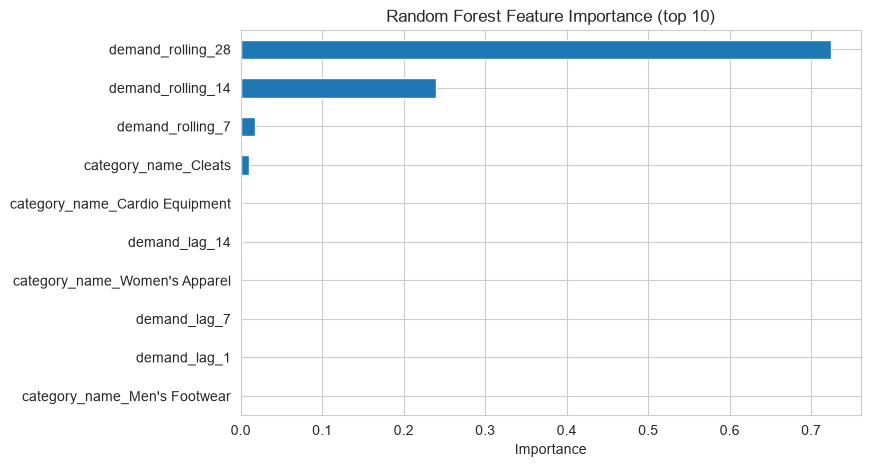

In [17]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(10).round(3))
imp.head(10).sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest Feature Importance (top 10)')
plt.xlabel('Importance')
plt.show()

### 4.2 Models

- **Baseline:** tomorrow's demand equals the 7-day rolling average already in the data (no model).
- **Linear Regression:** a single linear equation over all features.
- **Random Forest:** `max_depth` and `min_samples_leaf` are chosen on the **validation** set, not the test set.
- **Residual Random Forest:** predicts the *correction* to the rolling average (demand − rolling-7), then adds
  the rolling average back. This focuses the model on what the baseline gets wrong.

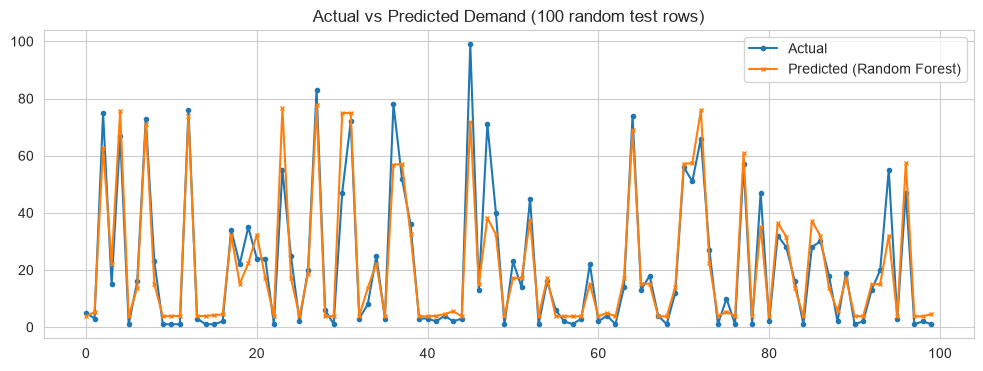

In [18]:
sample = np.random.choice(len(y_test), size=100, replace=False)
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[sample], label='Actual', marker='o', ms=3)
plt.plot(np.asarray(rf.predict(X_test))[sample], label='Predicted (Random Forest)', marker='x', ms=3)
plt.legend()
plt.title('Actual vs Predicted Demand (100 random test rows)')
plt.show()

**Insight:**
- The rolling-average baseline is hard to beat. The best model (Residual Random Forest) reduces MAE from
  5.31 to 5.19, a 2% improvement, with a slightly better R² (0.873 vs. 0.869).
- A plain Random Forest barely improves on the baseline (MAE 5.24). Linear Regression is clearly worse
  (MAE 7.60): the lag and rolling features are highly correlated with each other, which makes ordinary
  least-squares coefficients unstable.
- The forecast is useful for planning, but it is mostly a smoothed version of recent demand. It does not
  anticipate spikes that the recent history does not already show.

In [19]:
# Only order-time information: fields like days_shipping_real and delivery_status are known only AFTER delivery
# and would leak the label. days_shipment_scheduled is the promised window, known when the order is placed.
clf = df.copy()
clf['month'] = clf['order_date'].dt.month
clf['day_of_week'] = clf['order_date'].dt.dayofweek
clf['is_weekend'] = clf['day_of_week'].isin([5, 6]).astype(int)

cat_cols = ['shipping_mode', 'order_region', 'category_name']
num_cols = ['order_item_quantity', 'sales', 'days_shipment_scheduled', 'month', 'day_of_week', 'is_weekend']
Xc = clf[cat_cols + num_cols]
yc = clf['late_delivery_risk']

clf_train = clf['order_date'] < '2017-04-01'
clf_val = (clf['order_date'] >= '2017-04-01') & (clf['order_date'] < '2017-07-01')
clf_test = clf['order_date'] >= '2017-07-01'
Xc_train, yc_train = Xc[clf_train], yc[clf_train]
Xc_val, yc_val = Xc[clf_val], yc[clf_val]
Xc_test, yc_test = Xc[clf_test], yc[clf_test]

print('train/val/test:', Xc_train.shape, Xc_val.shape, Xc_test.shape)
print('late rate by split:', yc_train.mean().round(3), yc_val.mean().round(3), yc_test.mean().round(3))

train/val/test: (140670, 9) (15480, 9) (15812, 9)
late rate by split: 0.549 0.536 0.552


### 4.3 What drives the forecast

Feature importance from the Random Forest shows that the **28-day and 14-day rolling averages** carry
almost all of the signal (0.73 and 0.24). The 7-day average is less useful, and category identity, weekday,
and month add very little.

In [20]:
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])

lr_clf = Pipeline([('prep', preprocess), ('model', LogisticRegression(max_iter=1000))])
rf_clf = Pipeline([('prep', preprocess),
                   ('model', RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                                    random_state=42, n_jobs=-1))])
lr_clf.fit(Xc_train, yc_train)
rf_clf.fit(Xc_train, yc_train)

# Default threshold (0.5) on the test set
for name, m in [('Logistic Regression', lr_clf), ('Random Forest', rf_clf)]:
    print(f'--- {name} (default threshold 0.5) ---')
    print(classification_report(yc_test, m.predict(Xc_test), digits=3))

--- Logistic Regression (default threshold 0.5) ---
              precision    recall  f1-score   support

           0      0.612     0.880     0.722      7091
           1      0.849     0.547     0.665      8721

    accuracy                          0.696     15812
   macro avg      0.730     0.714     0.694     15812
weighted avg      0.743     0.696     0.691     15812

--- Random Forest (default threshold 0.5) ---
              precision    recall  f1-score   support

           0      0.612     0.880     0.722      7091
           1      0.848     0.547     0.665      8721

    accuracy                          0.696     15812
   macro avg      0.730     0.713     0.694     15812
weighted avg      0.743     0.696     0.691     15812



**Insight:** Predictions follow the general level of demand but smooth over sharp day-to-day spikes,
which is consistent with a model that relies on a rolling average rather than on day-specific shocks.

In [21]:
# Choose each model's threshold on cross-validated TRAINING probabilities only (test is not used for tuning)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tuned_threshold(pipe):
    # Youden's J = TPR - FPR (balanced accuracy). F1 is avoided here: with ~55% late orders,
    # F1 is maximised by flagging almost every order as late.
    proba = cross_val_predict(pipe, Xc_train, yc_train, cv=skf, method='predict_proba')[:, 1]
    fpr, tpr, t = roc_curve(yc_train, proba)
    return t[np.argmax(tpr - fpr)]

lr_threshold = tuned_threshold(lr_clf)
rf_threshold = tuned_threshold(rf_clf)
print(f'Logistic Regression threshold: {lr_threshold:.4f}')
print(f'Random Forest threshold:       {rf_threshold:.4f}')

Logistic Regression threshold: 0.6760
Random Forest threshold:       0.5191


## Section 5: Late Delivery Risk (Classification)

The model predicts, at the time an order is placed, whether it will arrive late. It uses only information
available at that point.

**Excluded on purpose:** `days_shipping_real` and `delivery_status` are only known after delivery and would
leak the answer. `days_shipment_scheduled` is the promised window and is known at order time, so it is used.

Features: shipping mode, order region, category, order quantity, sales, scheduled shipping days, month,
day of week, and weekend flag. The split is by date, as in Section 4.

--- Logistic Regression (tuned threshold 0.6760) ---
              precision    recall  f1-score   support

           0      0.612     0.880     0.722      7091
           1      0.849     0.547     0.665      8721

    accuracy                          0.696     15812
   macro avg      0.730     0.714     0.694     15812
weighted avg      0.743     0.696     0.691     15812

test decisions changed vs default 0.5: 0 of 15812
--- Random Forest (tuned threshold 0.5191) ---
              precision    recall  f1-score   support

           0      0.612     0.880     0.722      7091
           1      0.849     0.547     0.665      8721

    accuracy                          0.696     15812
   macro avg      0.730     0.714     0.694     15812
weighted avg      0.743     0.696     0.691     15812

test decisions changed vs default 0.5: 6 of 15812


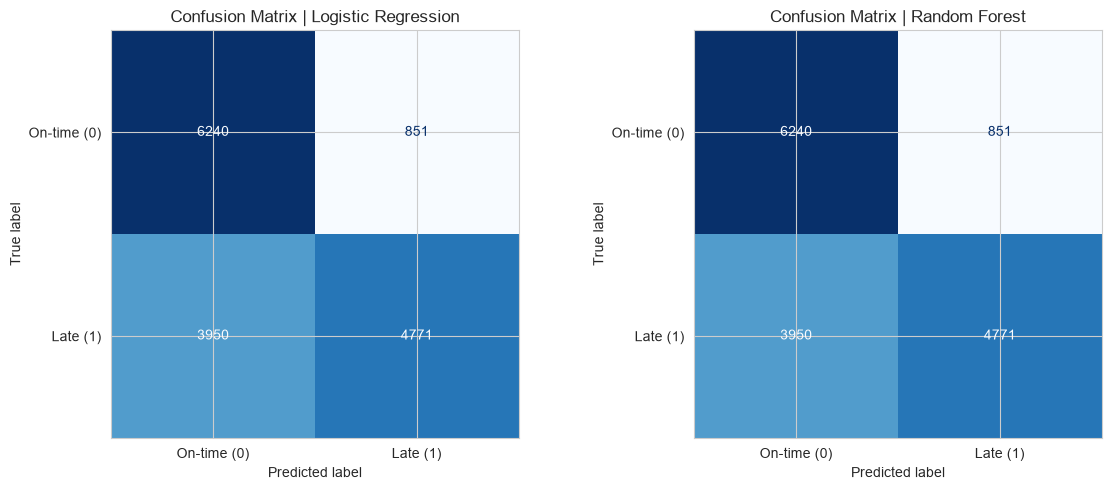

In [22]:
lr_prob_test = lr_clf.predict_proba(Xc_test)[:, 1]
rf_prob_test = rf_clf.predict_proba(Xc_test)[:, 1]

tuned_results = {}
for name, prob, thr in [('Logistic Regression', lr_prob_test, lr_threshold),
                        ('Random Forest', rf_prob_test, rf_threshold)]:
    pred = (prob >= thr).astype(int)
    print(f'--- {name} (tuned threshold {thr:.4f}) ---')
    print(classification_report(yc_test, pred, digits=3))
    default_pred = (prob >= 0.5).astype(int)
    print(f'test decisions changed vs default 0.5: {(pred != default_pred).sum()} of {len(pred)}')
    tuned_results[name] = pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, tuned_results.items()):
    ConfusionMatrixDisplay(confusion_matrix(yc_test, pred),
                           display_labels=['On-time (0)', 'Late (1)']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix | {name}')
plt.tight_layout()
plt.show()

### 5.1 Class balance

About 55% of orders are late in train, validation, and test alike. The split is therefore close to balanced
and no resampling is needed. Accuracy is still reported, alongside precision, recall, and ROC/PR-AUC.

In [23]:
rows = []
for name, prob in [('Logistic Regression', lr_prob_test), ('Random Forest', rf_prob_test)]:
    rows.append({'model': name,
                 'ROC-AUC': roc_auc_score(yc_test, prob),
                 'PR-AUC': average_precision_score(yc_test, prob)})
clf_scores = pd.DataFrame(rows).round(3)
print(clf_scores.to_string())

                 model  ROC-AUC  PR-AUC
0  Logistic Regression    0.735   0.799
1        Random Forest    0.740   0.797


### 5.2 Default threshold

Both models are first evaluated at the default 0.5 threshold. At this threshold they catch about 55% of late
orders, with precision 0.85 on late orders. Logistic Regression and Random Forest perform the same.

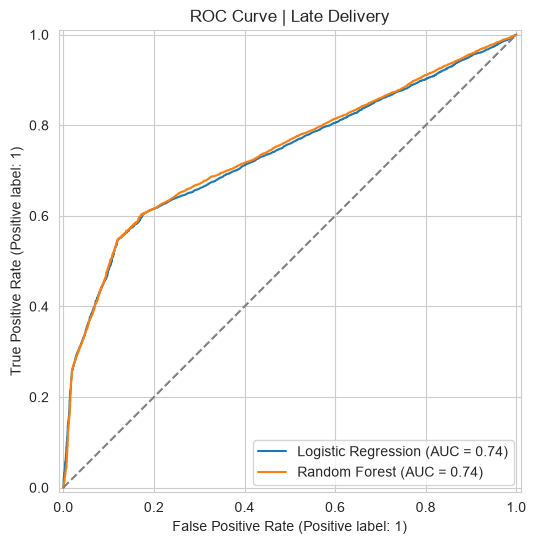

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(yc_test, lr_prob_test, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(yc_test, rf_prob_test, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], '--', color='grey')
ax.set_title('ROC Curve | Late Delivery')
plt.show()

### 5.3 Threshold check

The threshold is chosen on **cross-validated training probabilities** (Youden's J, which balances catching
late orders against false alarms). F1 was avoided on purpose: with 55% late orders, F1 is maximised by
flagging almost every order.

The check matters: the tuned thresholds (Logistic Regression 0.676, Random Forest 0.519) change **0** and
**6** of 15,812 test decisions respectively. Threshold tuning does not change the outcome for this data, so the
default threshold is kept in the conclusions. The probabilities are concentrated around a few values because
the main features are categorical (shipping mode), which is why a threshold shift affects so few orders.

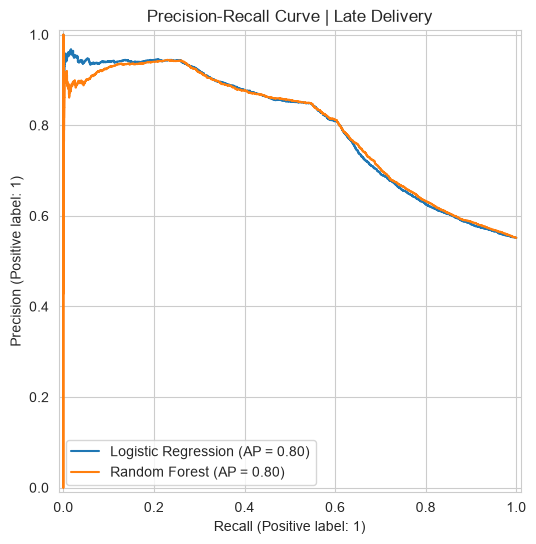

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(yc_test, lr_prob_test, name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_predictions(yc_test, rf_prob_test, name='Random Forest', ax=ax)
ax.set_title('Precision-Recall Curve | Late Delivery')
plt.show()

### 5.4 Ranking quality

On the test set the two models rank orders about equally well: ROC-AUC 0.74 and PR-AUC 0.80. The PR-AUC
should be compared with the base rate (0.55): a random ordering would score about 0.55. The model is
useful for prioritising orders, but it is not precise enough to be the only control.

num__days_shipment_scheduled         0.322
cat__shipping_mode_Standard Class    0.311
cat__shipping_mode_First Class       0.212
cat__shipping_mode_Second Class      0.095
cat__shipping_mode_Same Day          0.041
num__day_of_week                     0.003
num__month                           0.003
num__sales                           0.002
num__order_item_quantity             0.001
cat__order_region_South America      0.001
num__is_weekend                      0.001
cat__order_region_Canada             0.001
dtype: float64


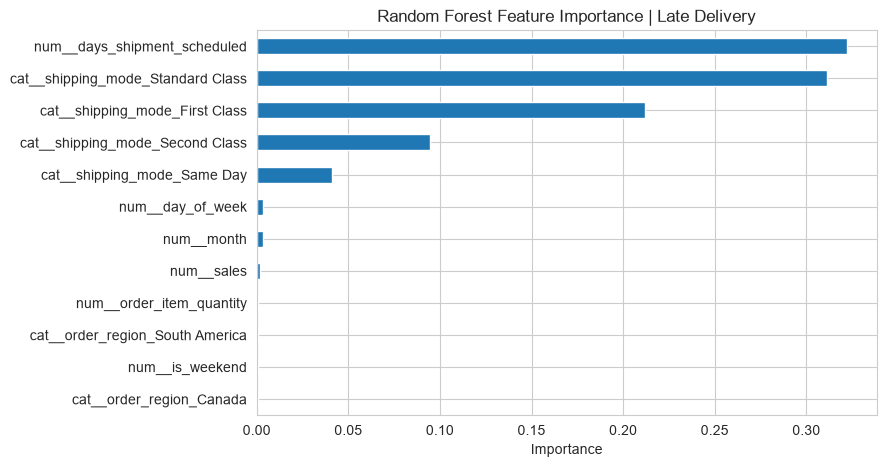

In [26]:
feature_names = rf_clf.named_steps['prep'].get_feature_names_out()
clf_importance = pd.Series(rf_clf.named_steps['model'].feature_importances_, index=feature_names)
clf_importance = clf_importance.sort_values(ascending=False)
print(clf_importance.head(12).round(3))
clf_importance.head(12).sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest Feature Importance | Late Delivery')
plt.xlabel('Importance')
plt.show()

### 5.5 What drives late delivery

Both models agree on the drivers: the promised shipping window (`days_shipment_scheduled`, the largest
single importance) and shipping mode. First Class has the largest positive coefficient, Same Day and
Standard Class the negative ones. Region and category contribute little beyond these.

In [27]:
coefs = pd.Series(lr_clf.named_steps['model'].coef_[0], index=feature_names).sort_values()
print(coefs.round(3))

cat__shipping_mode_Same Day               -1.527
cat__shipping_mode_Standard Class         -0.600
num__days_shipment_scheduled              -0.412
cat__order_region_Canada                  -0.362
cat__category_name_Trade-In               -0.051
cat__category_name_Women's Apparel        -0.043
cat__category_name_Girls' Apparel         -0.038
num__sales                                -0.036
cat__category_name_Indoor/Outdoor Games   -0.029
cat__order_region_Caribbean               -0.028
cat__category_name_Shop By Sport          -0.027
cat__category_name_Baseball & Softball    -0.027
cat__order_region_US Center               -0.018
cat__order_region_West of USA             -0.015
cat__category_name_Hockey                 -0.012
num__month                                -0.011
cat__category_name_Men's Footwear         -0.011
cat__category_name_Golf Balls             -0.007
num__day_of_week                          -0.004
cat__order_region_Southern Europe          0.000
cat__order_region_We

## Section 6: Business Narrative & Recommendations

**Demand forecasting.** Daily category demand is highly persistent: the recent 28-day average carries most
of the predictable signal. The best model improves on the simple rolling-average baseline by about 2% (MAE
5.19 vs. 5.31). For planning purposes, the rolling average is a strong starting point, and the extra model
adds little. Planning should therefore focus on safety stock for volatile categories (see Section 2.4) rather
than on a more complex forecast.

**Late delivery.** Shipping mode and the scheduled delivery window explain most of the late-delivery risk.
First Class orders are late 95% of the time, and Standard Class 38%. The model identifies riskier orders with
moderate accuracy (ROC-AUC 0.74), which is enough to prioritise a review queue at order placement.

**Recommendations**
1. **Review First and Second Class promises.** Late rates of 95% and 77% suggest the promised windows are
   tighter than the network can reliably meet. Check the scheduled days against actual performance before
   changing the carrier mix.
2. **Use the late-risk flag at order placement.** Route the highest-risk orders to expediting or proactive
   customer communication, rather than reacting after the delivery is already late.
3. **Set safety stock by category volatility.** Categories with high demand variance (Lacrosse, Golf Bags &
   Carts, Tennis & Racquet) need larger buffers than stable ones (Water Sports, Cleats, Women's Apparel).
4. **Address the high-risk region–category pairs** (for example Central Asia and Southern Africa) with
   region-specific carrier or fulfilment checks rather than a global change.

**Limitations**
- The raw data stops in mid-October 2017, so only about 2.75 years of history are used, and yearly
  seasonality can only be seen once.
- No promotion, stockout, price, or external-event data is available. These are the most likely drivers of
  demand spikes that the model cannot anticipate.
- The late-delivery model reaches ROC-AUC 0.74. It should support prioritisation, not automated decisions.
- Results come from one date-based split. Performance could differ in other periods.
- Random Forest uses hyperparameters chosen on validation data only; no broader search was run.